# 🐶🐱 Pet Breed Classification using TensorFlow

## Project Overview

This project classifies cat and dog breeds using transfer learning with the ResNet50 deep learning model. Images from the Oxford-IIIT Pet Dataset are preprocessed and used to train a classifier capable of predicting the breed of a pet image. The project includes data preprocessing, model training, evaluation, visualization of results, and prediction on unseen images.

## Import Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import glob
import os

## Set Dataset Path

In [8]:
images_file_path = "images"

## Read Image Names

In [9]:
image_names = [
    os.path.basename(file)
    for file in glob.glob(os.path.join(images_file_path, "*.jpg"))
]

In [10]:
len(image_names)

7390

In [11]:
image_names[:10]

['Egyptian_Mau_167.jpg',
 'pug_52.jpg',
 'basset_hound_112.jpg',
 'Siamese_193.jpg',
 'shiba_inu_122.jpg',
 'Siamese_53.jpg',
 'Birman_167.jpg',
 'leonberger_6.jpg',
 'Siamese_47.jpg',
 'shiba_inu_136.jpg']

## Create Labels

In [12]:
labels = [
    " ".join(name.split("_")[:-1])
    for name in image_names
]

In [13]:
labels[:10]

['Egyptian Mau',
 'pug',
 'basset hound',
 'Siamese',
 'shiba inu',
 'Siamese',
 'Birman',
 'leonberger',
 'Siamese',
 'shiba inu']

## Encode Labels

In [14]:
unique_labels = sorted(set(labels))

label_to_index = {
    label: index
    for index, label in enumerate(unique_labels)
}

In [15]:
encoded_labels = [
    label_to_index[label]
    for label in labels
]

In [16]:
encoded_labels[:10]

[5, 29, 14, 10, 33, 10, 2, 25, 10, 33]

In [17]:
label_to_index

{'Abyssinian': 0,
 'Bengal': 1,
 'Birman': 2,
 'Bombay': 3,
 'British Shorthair': 4,
 'Egyptian Mau': 5,
 'Maine Coon': 6,
 'Persian': 7,
 'Ragdoll': 8,
 'Russian Blue': 9,
 'Siamese': 10,
 'Sphynx': 11,
 'american bulldog': 12,
 'american pit bull terrier': 13,
 'basset hound': 14,
 'beagle': 15,
 'boxer': 16,
 'chihuahua': 17,
 'english cocker spaniel': 18,
 'english setter': 19,
 'german shorthaired': 20,
 'great pyrenees': 21,
 'havanese': 22,
 'japanese chin': 23,
 'keeshond': 24,
 'leonberger': 25,
 'miniature pinscher': 26,
 'newfoundland': 27,
 'pomeranian': 28,
 'pug': 29,
 'saint bernard': 30,
 'samoyed': 31,
 'scottish terrier': 32,
 'shiba inu': 33,
 'staffordshire bull terrier': 34,
 'wheaten terrier': 35,
 'yorkshire terrier': 36}

## Import TensorFlow

In [18]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [19]:
features = []

image_size = (224, 224)

In [20]:
for file_name in image_names:
    image = load_img(
        os.path.join(images_file_path, file_name),
        target_size=image_size
    )

    image = img_to_array(image)

    features.append(image)

In [21]:
len(features)

7390

In [22]:
features_array = np.array(features)
labels_array = np.array(encoded_labels)

## One-Hot Encoding

In [23]:
labels_one_hot = pd.get_dummies(labels_array)

In [24]:
labels_one_hot.head()

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    features_array,
    labels_one_hot,
    test_size=0.2,
    random_state=42
)

In [27]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=1
)

In [28]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (4434, 224, 224, 3)
Validation: (1478, 224, 224, 3)
Testing: (1478, 224, 224, 3)


## Build the Deep Learning Model

In [29]:
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras.layers import (
    RandomFlip,
    RandomRotation,
    Dropout,
    Dense
)

from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

In [30]:
data_augmentation = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2)
])

In [31]:
prediction_layer = Dense(
    len(unique_labels),
    activation="softmax"
)

In [32]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [33]:
inputs = Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(x, training=False)

x = Dropout(0.2)(x)

outputs = prediction_layer(x)

model = Model(inputs, outputs)

In [34]:
model.compile(
    optimizer=Adam(),
    loss=CategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [35]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2048)      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ resnet50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 37)        │     75,813 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,663,525 (90.27 MB)

 Trainable params: 75,813 (296.14 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [47]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=4,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 196s 175ms/step - accuracy: 0.8647 - loss: 0.5169 - val_accuracy: 0.8539 - val_loss: 0.7190
Epoch 2/10
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 196s 177ms/step - accuracy: 0.8658 - loss: 0.5358 - val_accuracy: 0.8376 - val_loss: 0.8566
Epoch 3/10
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 208s 188ms/step - accuracy: 0.8787 - loss: 0.4790 - val_accuracy: 0.8640 - val_loss: 0.7063
Epoch 4/10
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 197s 177ms/step - accuracy: 0.8832 - loss: 0.4815 - val_accuracy: 0.8633 - val_loss: 0.6955
Epoch 5/10
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 196s 177ms/step - accuracy: 0.8829 - loss: 0.4653 - val_accuracy: 0.8627 - val_loss: 0.6934


## Training and Validation Accuracy & Loss

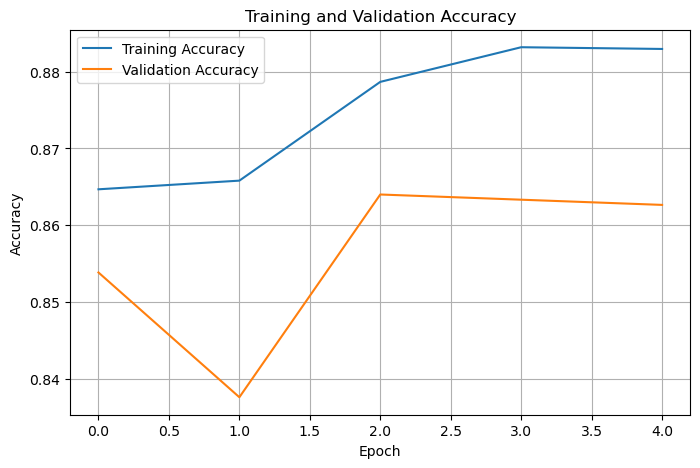

In [48]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

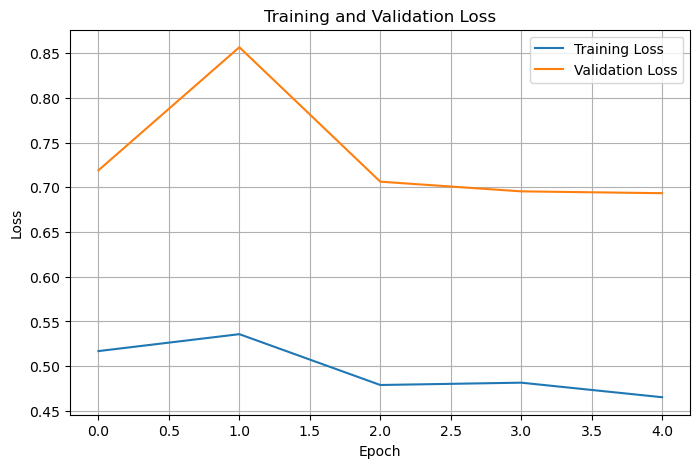

In [49]:
# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model Evaluation

In [50]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 42s 888ms/step - accuracy: 0.8552 - loss: 0.7174
Test Loss: 0.7173727750778198
Test Accuracy: 0.8552097678184509


## Save the Model

In [51]:
model.save("pet_breed_classifier.keras")

print("Model saved successfully!")

Model saved successfully!


## Predict on a Sample Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


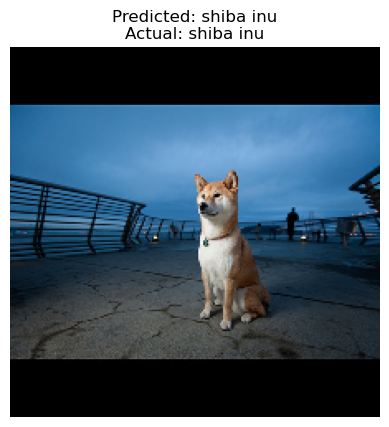

In [59]:
import random
import matplotlib.pyplot as plt

index = random.randint(0, len(X_test)-1)

image = X_test[index]

prediction = model.predict(image.reshape(1,224,224,3))

predicted_class = prediction.argmax()
actual_class = y_test.iloc[index].values.argmax()

predicted_breed = unique_labels[predicted_class]
actual_breed = unique_labels[actual_class]

plt.imshow(image.astype("uint8"))
plt.title(f"Predicted: {predicted_breed}\nActual: {actual_breed}")
plt.axis("off")
plt.show()